In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# =============================================================
# 1. LOAD DATA
# =============================================================
data = pd.read_csv('/Users/muhammadzuamaalamin/Documents/percobaancvd/datasetfix/heart_disease_new_dataset1.csv')
print("Shape awal:", data.shape)
print(data['CVD_LABEL'].value_counts())

Shape awal: (438693, 304)
CVD_LABEL
Healt                391852
Stroke Only           11518
CHD Only              11048
Heart Attack Only     10295
MI + CHD               8285
MI + Stroke            2137
All Three              2114
CHD + Stroke           1444
Name: count, dtype: int64


## preprocessing1

In [3]:
# =============================================================
# 2. HAPUS KOLOM MISSING VALUES >= 30%
# =============================================================
miss = data.isnull().mean() * 100
cols_to_drop_miss = miss[miss >= 30].index.tolist()

print(f"\nKolom dihapus karena missing >= 30% ({len(cols_to_drop_miss)}):")
print(cols_to_drop_miss)

data1 = data.drop(columns=cols_to_drop_miss)
print(f"\nShape setelah hapus missing: {data1.shape}")


Kolom dihapus karena missing >= 30% (155):
['CTELENM1', 'PVTRESD1', 'COLGHOUS', 'STATERE1', 'CELPHON1', 'LADULT1', 'COLGSEX', 'NUMADULT', 'LANDSEX', 'NUMMEN', 'NUMWOMEN', 'RESPSLCT', 'CCLGHOUS', 'POORHLTH', 'BPMEDS', 'ASTHNOW', 'DIABAGE3', 'ARTHEXER', 'ARTHEDU', 'LMTJOIN3', 'ARTHDIS2', 'JOINPAI2', 'NUMHHOL3', 'NUMPHON3', 'PREGNANT', 'SMOKDAY2', 'AVEDRNK3', 'DRNK3GE5', 'MAXDRNKS', 'FLSHTMY3', 'IMFVPLA2', 'HIVTSTD3', 'PDIABTST', 'PREDIAB1', 'INSULIN1', 'BLDSUGAR', 'FEETCHK3', 'DOCTDIAB', 'CHKHEMO3', 'FEETCHK', 'EYEEXAM1', 'DIABEYE', 'DIABEDU', 'TOLDCFS', 'HAVECFS', 'WORKCFS', 'TOLDHEPC', 'TRETHEPC', 'PRIRHEPC', 'HAVEHEPC', 'HAVEHEPB', 'MEDSHEPB', 'HPVADVC4', 'HPVADSHT', 'TETANUS1', 'SHINGLE2', 'LCSFIRST', 'LCSLAST', 'LCSNUMCG', 'LCSCTSCN', 'HADMAM', 'HOWLONG', 'CERVSCRN', 'CRVCLCNC', 'CRVCLPAP', 'CRVCLHPV', 'HADHYST2', 'PSATEST1', 'PSATIME1', 'PCPSARS2', 'PCSTALK', 'HADSIGM4', 'COLNSIGM', 'COLNTES1', 'SIGMTES1', 'LASTSIG4', 'COLNCNCR', 'VIRCOLO1', 'VCLNTES1', 'SMALSTOL', 'STOLTEST', 'ST

In [4]:
# ============================================================
# DEFINISI FITUR (sudah deduplikasi)
# ============================================================
fitur_paper = [
    # --- Cardiovascular / Target ---
    'CVD_LABEL',    # Label/Target
    '_MICHD',       # Heart Problems (CHD/MI)
    'CVDSTRK3',     # Stroke
    'CVDCRHD4',     # Coronary Heart Disease
    'CVDINFR4',     # Heart Attack

    # --- Blood Pressure & Cholesterol ---
    '_RFHYPE6',     # High Blood Pressure (calculated)
    'BPHIGH6',      # Ever Told Blood Pressure High
    'TOLDHI3',      # High Cholesterol
    '_CHOLCH3',     # Cholesterol Check (calculated)
    'CHOLCHK3',     # Cholesterol Check (raw)

    # --- Metabolic & Chronic Conditions ---
    'DIABETE4',     # Diabetes
    'CHCKDNY2',     # Kidney Disease
    'CHCCOPD3',     # COPD
    'ASTHMA3',      # Asthma
    'ADDEPEV3',     # Depression
    '_DRDXAR3',     # Arthritis

    # --- BMI ---
    '_BMI5',        # BMI (continuous)
    '_BMI5CAT',     # BMI Category

    # --- Lifestyle ---
    'SMOKE100',     # Smoker
    '_TOTINDA',     # Physical Activity
    '_FRTLT1A',     # Fruits Consumption
    '_VEGLT1A',     # Veggies Consumption
    '_DRNKWK1',     # Alcohol Consumption

    # --- Health Status ---
    'GENHLTH',      # General Health
    'MENTHLTH',     # Mental Health
    'PHYSHLTH',     # Physical Health
    'DIFFWALK',     # Difficulty Walking
    'DECIDE',       # Difficulty Concentrating/Deciding

    # --- Healthcare Access ---
    '_HLTHPLN',     # Any Healthcare Coverage
    'MEDCOST1',     # No Doc because Cost
    'PERSDOC3',     # Personal Doctor
    'CHECKUP1',     # Last Routine Checkup

    # --- Preventive Care ---
    'PNEUVAC4',     # Pneumonia Vaccine
    'FLUSHOT7',     # Flu Shot
    '_AIDTST4',     # HIV Test

    # --- Demographics ---
    '_SEX',         # Sex
    '_AGEG5YR',     # Age Group
    'EDUCA',        # Education
    'INCOME3',      # Income
    'EMPLOY1',      # Employment Status
    '_PRACE1',      # Race
]

# Hapus duplikat sambil pertahankan urutan
fitur_paper = list(dict.fromkeys(fitur_paper))

# ============================================================
# CEK KOLOM DIABETES
# ============================================================
diabetes_cols = [c for c in data1.columns if 'DIAB' in c.upper()]
print("Kolom diabetes yang tersedia:", diabetes_cols)

# ============================================================
# CEK KETERSEDIAAN FITUR
# ============================================================
fitur_exist   = [c for c in fitur_paper if c in data1.columns]
fitur_missing = [c for c in fitur_paper if c not in data1.columns]

print(f"\n{'='*45}")
print(f"  Total fitur didefinisikan : {len(fitur_paper)}")
print(f"  Fitur ditemukan           : {len(fitur_exist)}")
print(f"  Fitur tidak ditemukan     : {len(fitur_missing)}")
print(f"{'='*45}")

if fitur_missing:
    print("\n⚠️  Fitur yang TIDAK ADA di dataset:")
    for i, col in enumerate(fitur_missing, 1):
        print(f"   {i:2}. {col}")

# ============================================================
# BUAT DATASET FINAL
# ============================================================
data_final = data1[fitur_exist].copy()

print(f"\n✅ Shape data final : {data_final.shape}")
print(f"\nFitur yang dipakai ({len(fitur_exist)} fitur):")
for i, col in enumerate(fitur_exist, 1):
    print(f"  {i:2}. {col}")

Kolom diabetes yang tersedia: ['DIABETE4']

  Total fitur didefinisikan : 41
  Fitur ditemukan           : 41
  Fitur tidak ditemukan     : 0

✅ Shape data final : (438693, 41)

Fitur yang dipakai (41 fitur):
   1. CVD_LABEL
   2. _MICHD
   3. CVDSTRK3
   4. CVDCRHD4
   5. CVDINFR4
   6. _RFHYPE6
   7. BPHIGH6
   8. TOLDHI3
   9. _CHOLCH3
  10. CHOLCHK3
  11. DIABETE4
  12. CHCKDNY2
  13. CHCCOPD3
  14. ASTHMA3
  15. ADDEPEV3
  16. _DRDXAR3
  17. _BMI5
  18. _BMI5CAT
  19. SMOKE100
  20. _TOTINDA
  21. _FRTLT1A
  22. _VEGLT1A
  23. _DRNKWK1
  24. GENHLTH
  25. MENTHLTH
  26. PHYSHLTH
  27. DIFFWALK
  28. DECIDE
  29. _HLTHPLN
  30. MEDCOST1
  31. PERSDOC3
  32. CHECKUP1
  33. PNEUVAC4
  34. FLUSHOT7
  35. _AIDTST4
  36. _SEX
  37. _AGEG5YR
  38. EDUCA
  39. INCOME3
  40. EMPLOY1
  41. _PRACE1


## Preprocessing 2

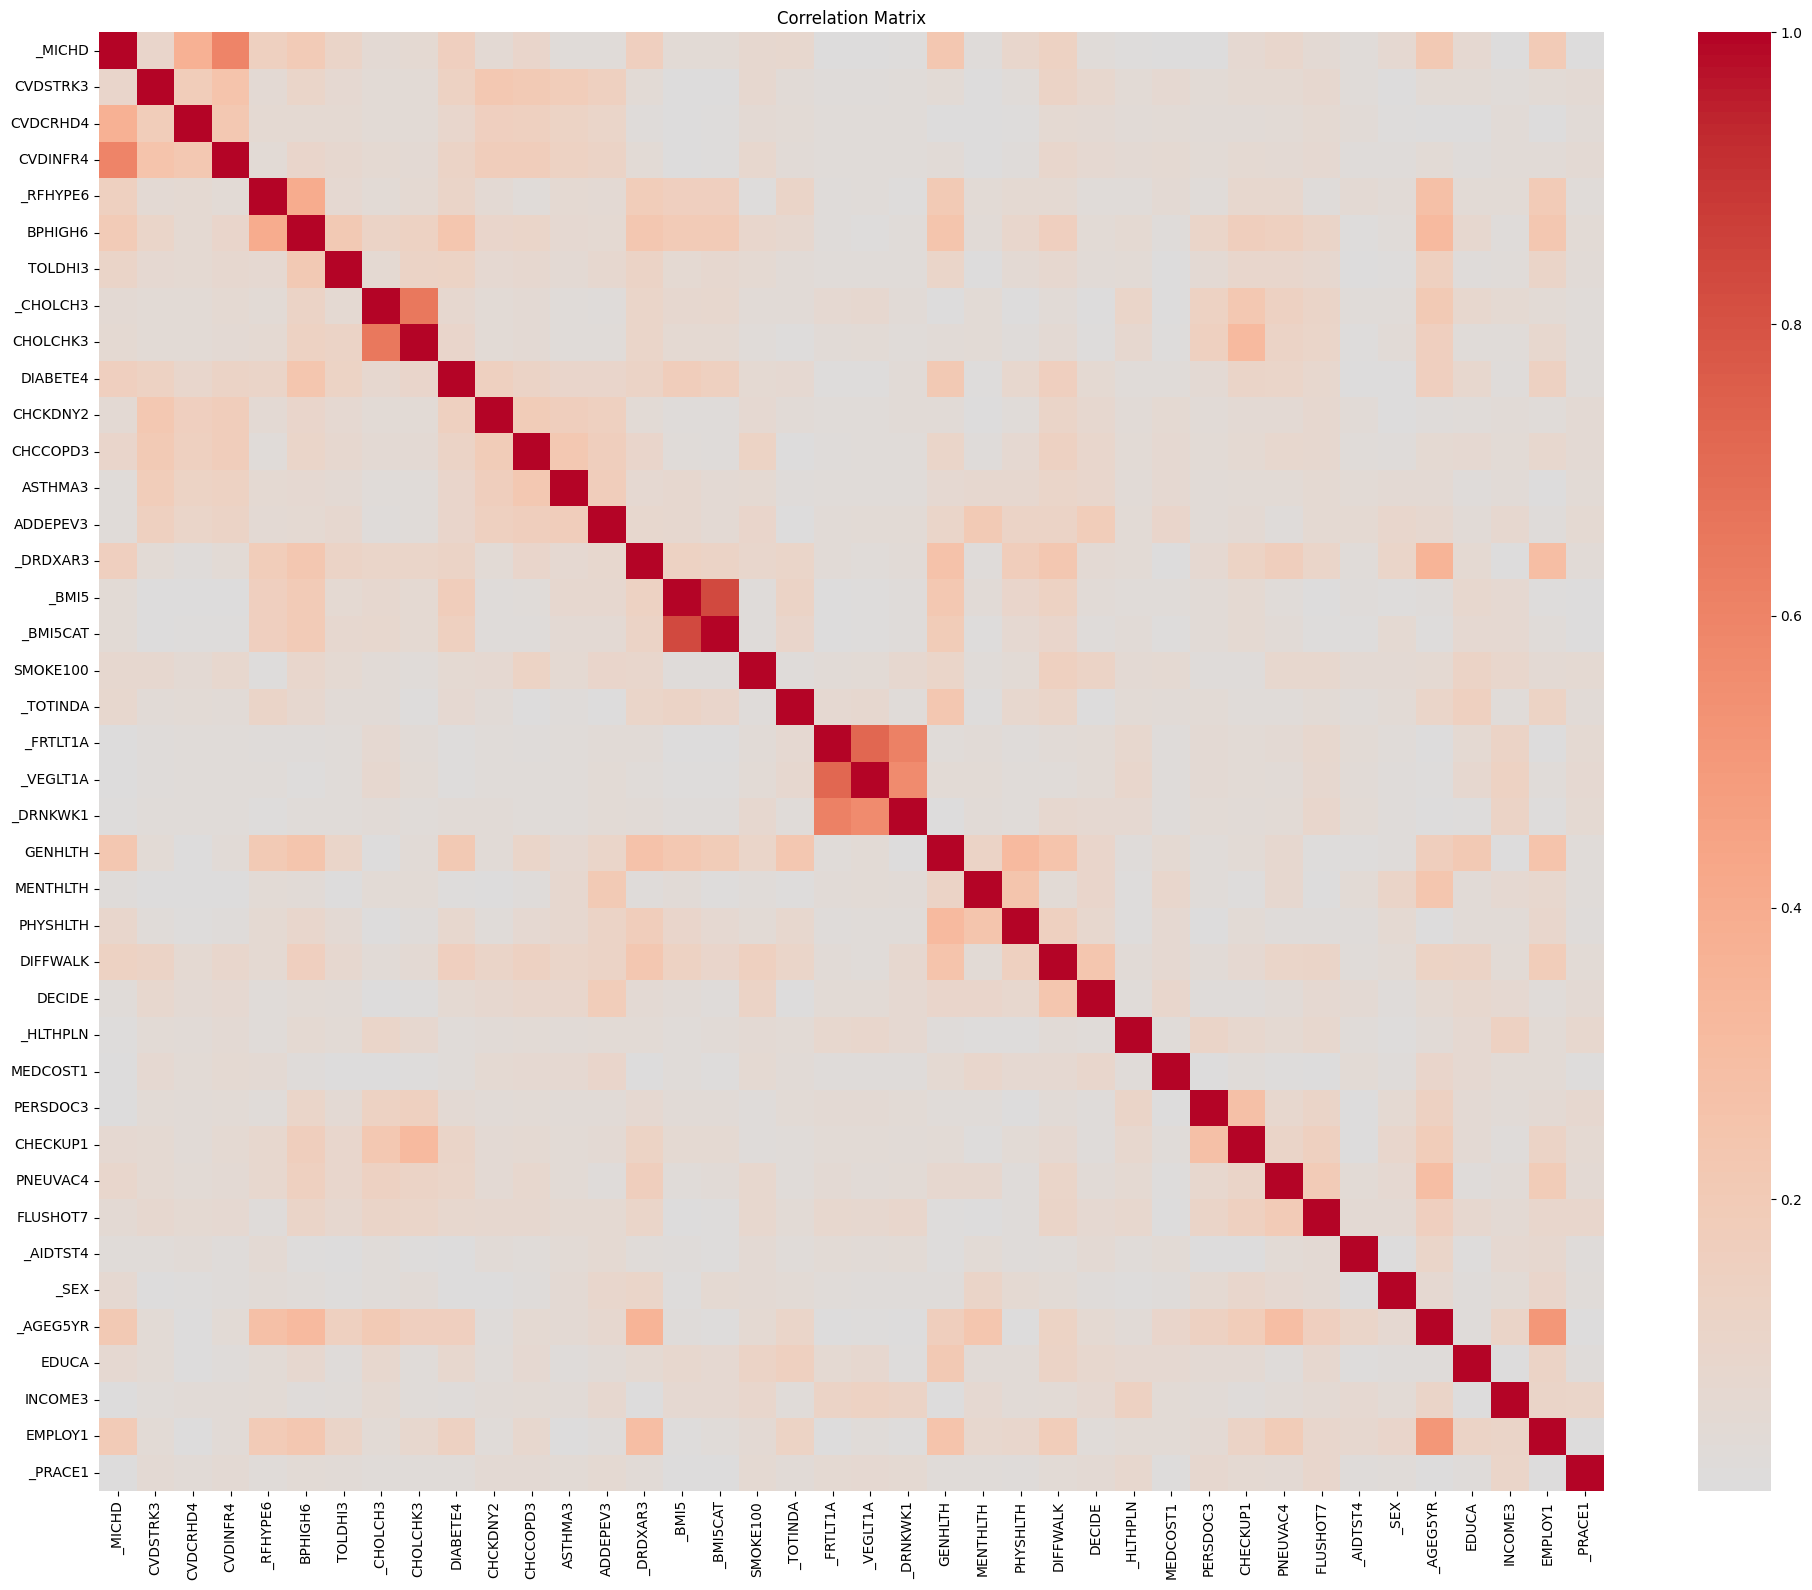

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Hitung korelasi
corr_matrix = data_final.select_dtypes(include='float64').corr().abs()

# Visualisasi heatmap
plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, 
            cmap='coolwarm',
            center=0,
            annot=False,  # ganti True kalau mau lihat angkanya (lambat kalau banyak fitur)
            fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [6]:
# Tampilkan pasangan fitur dengan korelasi > 0.85
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr = [(col, row, upper.loc[row, col]) 
             for col in upper.columns 
             for row in upper.index 
             if upper.loc[row, col] > 0.50]

high_corr_df = pd.DataFrame(high_corr, columns=['Fitur_1', 'Fitur_2', 'Korelasi'])
high_corr_df = high_corr_df.sort_values('Korelasi', ascending=False)

print(f"Pasangan fitur dengan korelasi > 0.85: {len(high_corr_df)}")
print(high_corr_df.to_string(index=False))

Pasangan fitur dengan korelasi > 0.85: 7
 Fitur_1  Fitur_2  Korelasi
_BMI5CAT    _BMI5  0.830420
_VEGLT1A _FRTLT1A  0.721476
CHOLCHK3 _CHOLCH3  0.648654
_DRNKWK1 _FRTLT1A  0.609881
CVDINFR4   _MICHD  0.600431
_DRNKWK1 _VEGLT1A  0.569375
 EMPLOY1 _AGEG5YR  0.511347


In [7]:
data_final = data_final.drop(columns=['_BMI5CAT'])

In [8]:
# Cara 1 - Value counts semua kolom sekaligus
for col in data_final.columns:
    print(f"\n{'='*50}")
    print(f"Kolom: {col}")
    print(data_final[col].value_counts(dropna=False))


Kolom: CVD_LABEL
CVD_LABEL
Healt                391852
Stroke Only           11518
CHD Only              11048
Heart Attack Only     10295
MI + CHD               8285
MI + Stroke            2137
All Three              2114
CHD + Stroke           1444
Name: count, dtype: int64

Kolom: _MICHD
_MICHD
2.0    398735
1.0     35323
NaN      4635
Name: count, dtype: int64

Kolom: CVDSTRK3
CVDSTRK3
2.0    420051
1.0     17213
7.0      1130
9.0       297
NaN         2
Name: count, dtype: int64

Kolom: CVDCRHD4
CVDCRHD4
2.0    411527
1.0     22891
7.0      3934
9.0       339
NaN         2
Name: count, dtype: int64

Kolom: CVDINFR4
CVDINFR4
2.0    413207
1.0     22831
7.0      2319
9.0       334
NaN         2
Name: count, dtype: int64

Kolom: _RFHYPE6
_RFHYPE6
1.0    264648
2.0    172133
9.0      1912
Name: count, dtype: int64

Kolom: BPHIGH6
BPHIGH6
3.0    256603
1.0    172133
4.0      4571
2.0      3474
7.0      1191
9.0       719
NaN         2
Name: count, dtype: int64

Kolom: TOLDHI3
TOLDHI3


In [9]:
import pandas as pd
import numpy as np

# Nilai yang perlu diganti NaN per variabel
nan_map = {
    'CVDSTRK3':  [7.0, 9.0],
    'CVDCRHD4':  [7.0, 9.0],
    'CVDINFR4':  [7.0, 9.0],
    'BPHIGH6':   [7.0, 9.0],
    'TOLDHI3':   [7.0, 9.0],
    '_CHOLCH3':  [9.0],
    'CHOLCHK3':  [7.0, 9.0],
    'DIABETE4':  [7.0, 9.0],
    'CHCKDNY2':  [7.0, 9.0],
    'CHCCOPD3':  [7.0, 9.0],
    'ASTHMA3':   [7.0, 9.0],
    'ADDEPEV3':  [7.0, 9.0],
    '_DRDXAR3':  [],           # sudah NaN semua
    'SMOKE100':  [7.0, 9.0],
    '_TOTINDA':  [9.0],
    '_FRTLT1A':  [9.0],
    '_VEGLT1A':  [9.0],
    'GENHLTH':   [7.0, 9.0],
    'MENTHLTH':  [77.0, 99.0],
    'PHYSHLTH':  [77.0, 99.0],
    'DIFFWALK':  [7.0, 9.0],
    'DECIDE':    [7.0, 9.0],
    '_HLTHPLN':  [9.0],
    'MEDCOST1':  [7.0, 9.0],
    'PERSDOC3':  [7.0, 9.0],
    'CHECKUP1':  [7.0, 8.0, 9.0],
    'PNEUVAC4':  [7.0, 9.0],
    'FLUSHOT7':  [7.0, 9.0],
    '_AIDTST4':  [9.0],
    'EDUCA':     [9.0],
    'INCOME3':   [77.0, 99.0],
    'EMPLOY1':   [9.0],
    '_PRACE1':   [77.0, 99.0],
}

for col, invalid_vals in nan_map.items():
    if col in data_final.columns and invalid_vals:
        data_final[col] = data_final[col].replace(invalid_vals, np.nan)

print("Selesai! Cek missing values:")
print(data_final[nan_map.keys()].isna().sum())

Selesai! Cek missing values:
CVDSTRK3     1429
CVDCRHD4     4275
CVDINFR4     2655
BPHIGH6      1912
TOLDHI3     63980
_CHOLCH3    29782
CHOLCHK3    29782
DIABETE4      985
CHCKDNY2     1813
CHCCOPD3     2107
ASTHMA3      1746
ADDEPEV3     2517
_DRDXAR3     2896
SMOKE100    24461
_TOTINDA      928
_FRTLT1A    51087
_VEGLT1A    60127
GENHLTH      1161
MENTHLTH     7917
PHYSHLTH     9494
DIFFWALK    19830
DECIDE      19980
_HLTHPLN    17397
MEDCOST1     1364
PERSDOC3     3705
CHECKUP1     8216
PNEUVAC4    62801
FLUSHOT7    31392
_AIDTST4    51856
EDUCA        2478
INCOME3     94413
EMPLOY1      8251
_PRACE1     13363
dtype: int64


In [10]:
data_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438693 entries, 0 to 438692
Data columns (total 40 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   CVD_LABEL  438693 non-null  object 
 1   _MICHD     434058 non-null  float64
 2   CVDSTRK3   437264 non-null  float64
 3   CVDCRHD4   434418 non-null  float64
 4   CVDINFR4   436038 non-null  float64
 5   _RFHYPE6   438693 non-null  float64
 6   BPHIGH6    436781 non-null  float64
 7   TOLDHI3    374713 non-null  float64
 8   _CHOLCH3   408911 non-null  float64
 9   CHOLCHK3   408911 non-null  float64
 10  DIABETE4   437708 non-null  float64
 11  CHCKDNY2   436880 non-null  float64
 12  CHCCOPD3   436586 non-null  float64
 13  ASTHMA3    436947 non-null  float64
 14  ADDEPEV3   436176 non-null  float64
 15  _DRDXAR3   435797 non-null  float64
 16  _BMI5      391841 non-null  float64
 17  SMOKE100   414232 non-null  float64
 18  _TOTINDA   437765 non-null  float64
 19  _FRTLT1A   387606 non-n

In [11]:
data_final.describe()

,_MICHD,CVDSTRK3,CVDCRHD4,CVDINFR4,_RFHYPE6,BPHIGH6,TOLDHI3,_CHOLCH3,CHOLCHK3,DIABETE4,...,CHECKUP1,PNEUVAC4,FLUSHOT7,_AIDTST4,_SEX,_AGEG5YR,EDUCA,INCOME3,EMPLOY1,_PRACE1
count,434058.000000,437264.000000,434418.000000,436038.000000,438693.000000,436781.000000,374713.000000,408911.000000,408911.000000,437708.000000,...,430477.000000,375892.000000,407301.000000,386837.000000,438693.000000,438693.000000,436215.000000,344280.000000,430442.000000,425330.000000
mean,1.918621,1.960635,1.947307,1.947640,1.427244,2.214323,1.600430,1.186539,2.405142,2.750752,...,1.356802,1.596778,1.479098,1.666506,1.535529,7.726016,5.012790,6.698330,3.747225,1.431935
std,0.273416,0.194463,0.223421,0.222752,0.699127,0.988691,0.489811,0.552422,1.300781,0.704141,...,0.772044,0.490545,0.499564,0.471462,0.498737,3.645926,1.007272,2.422855,2.837228,1.143380
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000,2.000000,3.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,4.000000,5.000000,1.000000,1.000000
50%,2.000000,2.000000,2.000000,2.000000,1.000000,3.000000,2.000000,1.000000,2.000000,3.000000,...,1.000000,2.000000,1.000000,2.000000,2.000000,8.000000,5.000000,7.000000,2.000000,1.000000
75%,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,2.000000,1.000000,2.000000,3.000000,...,1.000000,2.000000,2.000000,2.000000,2.000000,11.000000,6.000000,9.000000,7.000000,1.000000
max,2.000000,2.000000,2.000000,2.000000,9.000000,4.000000,2.000000,3.000000,8.000000,4.000000,...,4.000000,2.000000,2.000000,2.000000,2.000000,14.000000,6.000000,11.000000,8.000000,8.000000


In [12]:
data_final.isna().sum()

CVD_LABEL        0
_MICHD        4635
CVDSTRK3      1429
CVDCRHD4      4275
CVDINFR4      2655
_RFHYPE6         0
BPHIGH6       1912
TOLDHI3      63980
_CHOLCH3     29782
CHOLCHK3     29782
DIABETE4       985
CHCKDNY2      1813
CHCCOPD3      2107
ASTHMA3       1746
ADDEPEV3      2517
_DRDXAR3      2896
_BMI5        46852
SMOKE100     24461
_TOTINDA       928
_FRTLT1A     51087
_VEGLT1A     60127
_DRNKWK1         0
GENHLTH       1161
MENTHLTH      7917
PHYSHLTH      9494
DIFFWALK     19830
DECIDE       19980
_HLTHPLN     17397
MEDCOST1      1364
PERSDOC3      3705
CHECKUP1      8216
PNEUVAC4     62801
FLUSHOT7     31392
_AIDTST4     51856
_SEX             0
_AGEG5YR         0
EDUCA         2478
INCOME3      94413
EMPLOY1       8251
_PRACE1      13363
dtype: int64

In [13]:
severity_map = {
    'Healt'            : 0,  # Sehat
    'Stroke Only'       : 1,  # Level 1 → 1 kondisi
    'CHD Only'          : 1,  # Level 1 → 1 kondisi
    'Heart Attack Only' : 1,  # Level 1 → 1 kondisi
    'MI + CHD'          : 1,  # Level 2 → 2 kondisi
    'MI + Stroke'       : 1,  # Level 2 → 2 kondisi
    'CHD + Stroke'      : 1,  # Level 2 → 2 kondisi
    'All Three'         : 1,  # Level 3 → 3 kondisi
}

data_final['CVD_SEVERITY'] = data_final['CVD_LABEL'].map(severity_map)

# Verifikasi
print(data_final['CVD_SEVERITY'].value_counts())
print(f"\nTotal : {len(data1):,}")

CVD_SEVERITY
0    391852
1     46841
Name: count, dtype: int64

Total : 438,693


In [14]:
data_final.isnull().sum()

CVD_LABEL           0
_MICHD           4635
CVDSTRK3         1429
CVDCRHD4         4275
CVDINFR4         2655
_RFHYPE6            0
BPHIGH6          1912
TOLDHI3         63980
_CHOLCH3        29782
CHOLCHK3        29782
DIABETE4          985
CHCKDNY2         1813
CHCCOPD3         2107
ASTHMA3          1746
ADDEPEV3         2517
_DRDXAR3         2896
_BMI5           46852
SMOKE100        24461
_TOTINDA          928
_FRTLT1A        51087
_VEGLT1A        60127
_DRNKWK1            0
GENHLTH          1161
MENTHLTH         7917
PHYSHLTH         9494
DIFFWALK        19830
DECIDE          19980
_HLTHPLN        17397
MEDCOST1         1364
PERSDOC3         3705
CHECKUP1         8216
PNEUVAC4        62801
FLUSHOT7        31392
_AIDTST4        51856
_SEX                0
_AGEG5YR            0
EDUCA            2478
INCOME3         94413
EMPLOY1          8251
_PRACE1         13363
CVD_SEVERITY        0
dtype: int64

In [15]:
data_final

,CVD_LABEL,_MICHD,CVDSTRK3,CVDCRHD4,CVDINFR4,_RFHYPE6,BPHIGH6,TOLDHI3,_CHOLCH3,CHOLCHK3,...,PNEUVAC4,FLUSHOT7,_AIDTST4,_SEX,_AGEG5YR,EDUCA,INCOME3,EMPLOY1,_PRACE1,CVD_SEVERITY
0,Healt,2.0,2.0,2.0,2.0,1.0,3.0,1.0,1.0,2.0,...,1.0,1.0,2.0,2.0,11.0,4.0,5.0,7.0,1.0,0
1,CHD Only,1.0,2.0,1.0,2.0,2.0,1.0,1.0,1.0,2.0,...,2.0,2.0,2.0,2.0,10.0,6.0,NaN,8.0,2.0,1
2,CHD Only,1.0,2.0,1.0,2.0,2.0,1.0,2.0,1.0,2.0,...,2.0,2.0,2.0,2.0,11.0,4.0,3.0,7.0,2.0,1
3,Healt,2.0,2.0,2.0,2.0,2.0,1.0,1.0,1.0,2.0,...,2.0,1.0,2.0,2.0,9.0,4.0,7.0,7.0,1.0,0
4,MI + Stroke,1.0,1.0,NaN,1.0,1.0,4.0,1.0,1.0,2.0,...,1.0,1.0,1.0,1.0,12.0,3.0,4.0,8.0,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
438688,Healt,2.0,2.0,2.0,2.0,2.0,1.0,2.0,1.0,6.0,...,1.0,2.0,1.0,2.0,3.0,4.0,5.0,1.0,NaN,0
438689,Healt,2.0,2.0,2.0,2.0,2.0,1.0,2.0,1.0,2.0,...,2.0,2.0,2.0,1.0,13.0,4.0,1.0,8.0,6.0,0
438690,Healt,2.0,2.0,2.0,2.0,1.0,3.0,1.0,1.0,2.0,...,2.0,2.0,1.0,1.0,7.0,6.0,10.0,7.0,2.0,0
438691,Healt,2.0,2.0,2.0,2.0,2.0,1.0,2.0,1.0,2.0,...,2.0,2.0,1.0,1.0,10.0,4.0,6.0,7.0,NaN,0


In [16]:
data_final = data_final.drop(columns=['CVD_SEVERITY','CVD_LABEL','CVDINFR4','CVDCRHD4','INCOME3'])
data_final

,_MICHD,CVDSTRK3,_RFHYPE6,BPHIGH6,TOLDHI3,_CHOLCH3,CHOLCHK3,DIABETE4,CHCKDNY2,CHCCOPD3,...,PERSDOC3,CHECKUP1,PNEUVAC4,FLUSHOT7,_AIDTST4,_SEX,_AGEG5YR,EDUCA,EMPLOY1,_PRACE1
0,2.0,2.0,1.0,3.0,1.0,1.0,2.0,3.0,2.0,1.0,...,1.0,2.0,1.0,1.0,2.0,2.0,11.0,4.0,7.0,1.0
1,1.0,2.0,2.0,1.0,1.0,1.0,2.0,1.0,1.0,2.0,...,2.0,1.0,2.0,2.0,2.0,2.0,10.0,6.0,8.0,2.0
2,1.0,2.0,2.0,1.0,2.0,1.0,2.0,1.0,2.0,2.0,...,2.0,1.0,2.0,2.0,2.0,2.0,11.0,4.0,7.0,2.0
3,2.0,2.0,2.0,1.0,1.0,1.0,2.0,1.0,2.0,2.0,...,1.0,1.0,2.0,1.0,2.0,2.0,9.0,4.0,7.0,1.0
4,1.0,1.0,1.0,4.0,1.0,1.0,2.0,1.0,2.0,2.0,...,1.0,1.0,1.0,1.0,1.0,1.0,12.0,3.0,8.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
438688,2.0,2.0,2.0,1.0,2.0,1.0,6.0,2.0,2.0,1.0,...,3.0,4.0,1.0,2.0,1.0,2.0,3.0,4.0,1.0,NaN
438689,2.0,2.0,2.0,1.0,2.0,1.0,2.0,1.0,2.0,2.0,...,1.0,1.0,2.0,2.0,2.0,1.0,13.0,4.0,8.0,6.0
438690,2.0,2.0,1.0,3.0,1.0,1.0,2.0,3.0,2.0,2.0,...,1.0,1.0,2.0,2.0,1.0,1.0,7.0,6.0,7.0,2.0
438691,2.0,2.0,2.0,1.0,2.0,1.0,2.0,3.0,2.0,2.0,...,2.0,1.0,2.0,2.0,1.0,1.0,10.0,4.0,7.0,NaN


In [17]:
# data_new = data_final.dropna()
# print(f"Sebelum : {len(data1)} baris")
# print(f"Sesudah : {len(data_new)} baris")
# print(f"Terhapus: {len(data1) - len(data_new)} baris")

In [18]:
data_final ['_MICHD'].value_counts()

_MICHD
2.0    398735
1.0     35323
Name: count, dtype: int64

In [20]:
severity_map = {
    2.0: 0,
    1.0: 1,
    7.0: None,
    9.0: None
}
data_final ['_MICHD'] = data_final ['_MICHD'].map(severity_map)

# Verifikasi
print(data_final ['_MICHD'].value_counts())
print(f"\nTotal : {len(data1):,}")

_MICHD
0.0    398735
1.0     35323
Name: count, dtype: int64

Total : 438,693


In [21]:
data_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438693 entries, 0 to 438692
Data columns (total 36 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   _MICHD    434058 non-null  float64
 1   CVDSTRK3  437264 non-null  float64
 2   _RFHYPE6  438693 non-null  float64
 3   BPHIGH6   436781 non-null  float64
 4   TOLDHI3   374713 non-null  float64
 5   _CHOLCH3  408911 non-null  float64
 6   CHOLCHK3  408911 non-null  float64
 7   DIABETE4  437708 non-null  float64
 8   CHCKDNY2  436880 non-null  float64
 9   CHCCOPD3  436586 non-null  float64
 10  ASTHMA3   436947 non-null  float64
 11  ADDEPEV3  436176 non-null  float64
 12  _DRDXAR3  435797 non-null  float64
 13  _BMI5     391841 non-null  float64
 14  SMOKE100  414232 non-null  float64
 15  _TOTINDA  437765 non-null  float64
 16  _FRTLT1A  387606 non-null  float64
 17  _VEGLT1A  378566 non-null  float64
 18  _DRNKWK1  438693 non-null  float64
 19  GENHLTH   437532 non-null  float64
 20  MENT

In [22]:
from sklearn.model_selection import train_test_split
data_clean = data_final .dropna(subset=['_MICHD'])


# X = data_clean.drop(columns=['_MICHD'])
# y = data_clean['_MICHD']
data_sample = data_clean.sample(n=20000, random_state=42)
X = data_sample.drop(columns=['_MICHD'])
y = data_sample['_MICHD']

# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42, stratify=y
# )

In [23]:
# X = data_new.drop(columns=['_MICHD'])
# y = data_new['_MICHD']

## Training Model

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [27]:
y_train.value_counts()

_MICHD
0.0    14714
1.0     1286
Name: count, dtype: int64

### Imputasi

In [28]:
# simpan index
X_train_index = X_train.index
X_test_index = X_test.index

from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=5)

# imputasi
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

# balik ke dataframe
import pandas as pd

X_train = pd.DataFrame(X_train, columns=X.columns, index=X_train_index)
X_test = pd.DataFrame(X_test, columns=X.columns, index=X_test_index)

In [29]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16000 entries, 275213 to 302605
Data columns (total 35 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   CVDSTRK3  16000 non-null  float64
 1   _RFHYPE6  16000 non-null  float64
 2   BPHIGH6   16000 non-null  float64
 3   TOLDHI3   16000 non-null  float64
 4   _CHOLCH3  16000 non-null  float64
 5   CHOLCHK3  16000 non-null  float64
 6   DIABETE4  16000 non-null  float64
 7   CHCKDNY2  16000 non-null  float64
 8   CHCCOPD3  16000 non-null  float64
 9   ASTHMA3   16000 non-null  float64
 10  ADDEPEV3  16000 non-null  float64
 11  _DRDXAR3  16000 non-null  float64
 12  _BMI5     16000 non-null  float64
 13  SMOKE100  16000 non-null  float64
 14  _TOTINDA  16000 non-null  float64
 15  _FRTLT1A  16000 non-null  float64
 16  _VEGLT1A  16000 non-null  float64
 17  _DRNKWK1  16000 non-null  float64
 18  GENHLTH   16000 non-null  float64
 19  MENTHLTH  16000 non-null  float64
 20  PHYSHLTH  16000 non-null  f

## Feature Selection (Xgboost)

In [30]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score,recall_score

# Hitung scale_pos_weight untuk class imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Training model
model = XGBClassifier(
    n_estimators     = 100,
    max_depth        = 6,
    learning_rate    = 0.1,
    scale_pos_weight = scale_pos_weight,
    eval_metric      = 'logloss',
    random_state     = 42
)

model.fit(X_train, y_train)

# %%
# Evaluasi
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=['Sehat', 'CVD']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

       Sehat       0.96      0.84      0.90      3678
         CVD       0.25      0.62      0.36       322

    accuracy                           0.82      4000
   macro avg       0.61      0.73      0.63      4000
weighted avg       0.90      0.82      0.85      4000

AUC-ROC: 0.8347

Confusion Matrix:
[[3082  596]
 [ 123  199]]


Top 20 Feature Importance:
     feature  importance
0    BPHIGH6    0.133012
1    EMPLOY1    0.129447
2    GENHLTH    0.068522
3    TOLDHI3    0.061897
4   _AGEG5YR    0.044580
5       _SEX    0.038396
6   CVDSTRK3    0.031702
7   CHCCOPD3    0.030711
8   DIABETE4    0.027387
9   SMOKE100    0.026235
10  DIFFWALK    0.023617
11  PERSDOC3    0.022245
12  PNEUVAC4    0.021901
13  ADDEPEV3    0.020200
14  CHOLCHK3    0.020115
15  CHECKUP1    0.018651
16  _DRDXAR3    0.018362
17   ASTHMA3    0.017486
18  PHYSHLTH    0.017243
19   _PRACE1    0.016335
20  _DRNKWK1    0.016262
21     _BMI5    0.016054
22  _TOTINDA    0.015961
23  _AIDTST4    0.015409
24    DECIDE    0.014926
25  FLUSHOT7    0.014884
26  MEDCOST1    0.014523
27     EDUCA    0.014096
28  MENTHLTH    0.014057
29  _VEGLT1A    0.013790
30  _HLTHPLN    0.013510
31  _CHOLCH3    0.013158
32  CHCKDNY2    0.012093
33  _FRTLT1A    0.012077
34  _RFHYPE6    0.011158


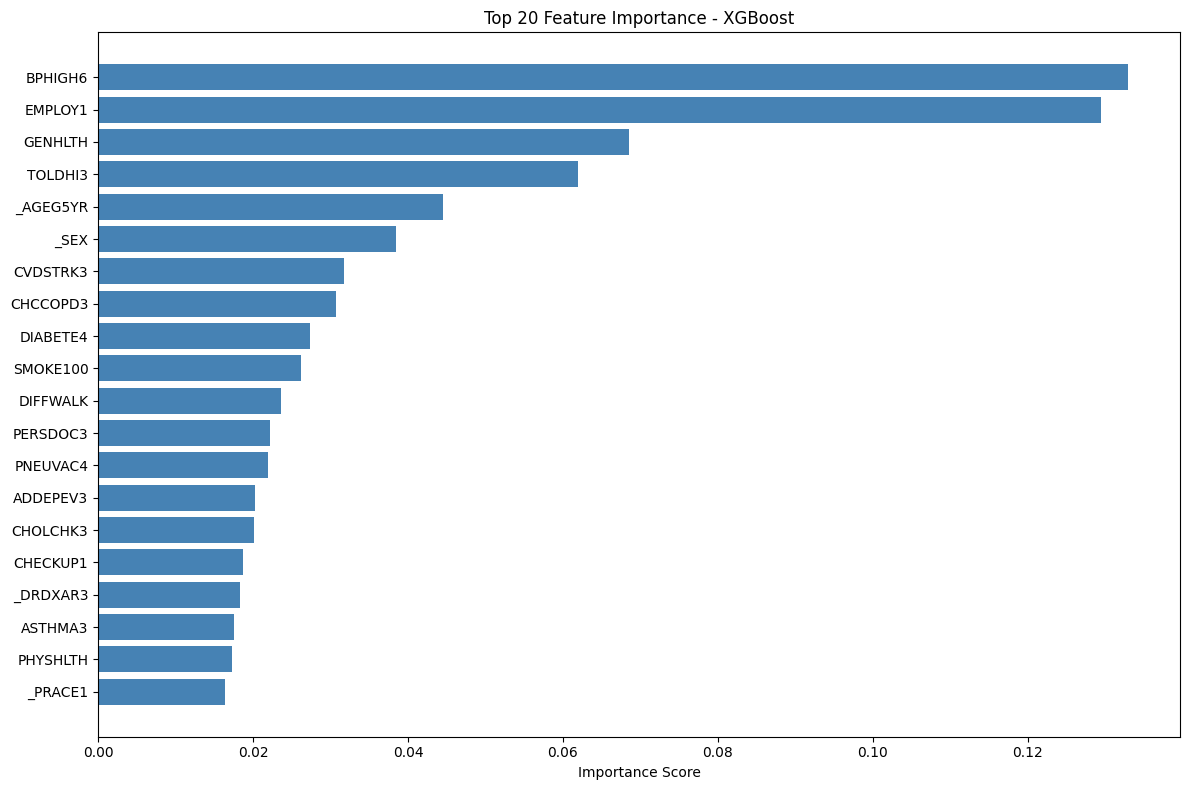

In [31]:
import matplotlib.pyplot as plt
# ── 1. Feature Importance dari model XGBoost yang sudah ditraining ──
importances = model.feature_importances_
feature_names = X_train.columns

feat_imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False).reset_index(drop=True)

print("Top 20 Feature Importance:")
print(feat_imp_df.head(50))

# %%
# ── 2. Plot Feature Importance ──
plt.figure(figsize=(12, 8))
top_n = 20
plt.barh(
    feat_imp_df['feature'][:top_n][::-1],
    feat_imp_df['importance'][:top_n][::-1],
    color='steelblue'
)
plt.xlabel('Importance Score')
plt.title(f'Top {top_n} Feature Importance - XGBoost')
plt.tight_layout()
plt.show()

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from imblearn.over_sampling import SMOTE, BorderlineSMOTE, ADASYN
from imblearn.combine import SMOTETomek, SMOTEENN
from imblearn.under_sampling import TomekLinks, NearMiss
from sklearn.metrics import (
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, recall_score, precision_score, accuracy_score,
    classification_report
)
from xgboost import XGBClassifier
import pandas as pd

# ── 1. Definisi kuartil & resamplers ─────────────────────────────────────────
kuartils = [1, 2, 3]

resamplers = {
    'scale_pos_weight' : None,
    'SMOTE'            : SMOTE(random_state=42),
    'BorderlineSMOTE'  : BorderlineSMOTE(random_state=42),
    'ADASYN'           : ADASYN(random_state=42),
    'SMOTETomek'       : SMOTETomek(random_state=42),
    'SMOTEENN'         : SMOTEENN(random_state=42),
    'TomekLinks'       : TomekLinks(n_jobs=-1),
    'NearMiss-1'       : NearMiss(version=1, n_jobs=-1),
    'NearMiss-2'       : NearMiss(version=2, n_jobs=-1),
    'NearMiss-3'       : NearMiss(version=3, n_jobs=-1),
}

N_total = len(feat_imp_df)  # ← dari XGBoost feature importance


# ── 2. Loop kuartil × resampler ───────────────────────────────────────────────
results_all   = {}
conf_matrices = {}

for Q in tqdm(kuartils, desc="Kuartil"):
    N_FEATURES        = int(np.ceil(N_total * Q / 4))
    selected_features = feat_imp_df['feature'].head(N_FEATURES).tolist()  # ← feat_imp_df

    X_train_q = X_train[selected_features]
    X_test_q  = X_test[selected_features]

    print(f"\n{'='*60}")
    print(f"  Kuartil Q={Q} ({Q*25}%) → {N_FEATURES} fitur")
    print(f"{'='*60}")

    for resampler_name, sampler in tqdm(resamplers.items(), desc=f"Q={Q}", leave=False):
        print(f"\n  [{resampler_name}]")

        # Resampling
        if sampler is None:
            X_res, y_res = X_train_q, y_train
            spw = (y_train == 0).sum() / (y_train == 1).sum()
        else:
            X_res, y_res = sampler.fit_resample(X_train_q, y_train)
            spw = 1.0

        print(f"  Shape train : {X_train_q.shape} → {X_res.shape}")

        # Retrain XGBoost
        xgb_fit = XGBClassifier(
            **{**model.get_params(), 'scale_pos_weight': spw}
        )
        xgb_fit.fit(X_res, y_res)

        y_pred = xgb_fit.predict(X_test_q)
        report = classification_report(y_test, y_pred, output_dict=True)

        print(classification_report(y_test, y_pred))

        key = f'Q{Q}_{resampler_name}'
        conf_matrices[key] = confusion_matrix(y_test, y_pred)
        results_all[key] = {
            'Kuartil'     : f'Q{Q} ({Q*25}%)',
            'N Fitur'     : N_FEATURES,
            'Resampler'   : resampler_name,
            'Accuracy'    : report['accuracy'],
            'F1 Macro'    : report['macro avg']['f1-score'],
            'F1 Weighted' : report['weighted avg']['f1-score'],
            'Precision'   : report['macro avg']['precision'],
            'Recall'      : report['macro avg']['recall'],
        }


# ── 3. Tabel perbandingan ─────────────────────────────────────────────────────
results_df = pd.DataFrame(results_all).T.round(4)
print("\n── Perbandingan Semua Kombinasi ──")
print(results_df.sort_values('F1 Macro', ascending=False).to_string())


# ── 4. Kombinasi terbaik ──────────────────────────────────────────────────────
best = results_df.sort_values('F1 Macro', ascending=False).iloc[0]
print(f"\n✅ Kombinasi terbaik:")
print(f"   Kuartil   : {best['Kuartil']}")
print(f"   N Fitur   : {best['N Fitur']}")
print(f"   Resampler : {best['Resampler']}")
print(f"   F1 Macro  : {best['F1 Macro']}")

Kuartil:   0%|          | 0/3 [00:00<?, ?it/s]


  Kuartil Q=1 (25%) → 9 fitur



  [scale_pos_weight]
  Shape train : (16000, 9) → (16000, 9)
              precision    recall  f1-score   support

         0.0       0.97      0.77      0.86      3678
         1.0       0.21      0.71      0.32       322

    accuracy                           0.76      4000
   macro avg       0.59      0.74      0.59      4000
weighted avg       0.91      0.76      0.81      4000


  [SMOTE]
  Shape train : (16000, 9) → (29428, 9)


              precision    recall  f1-score   support

         0.0       0.95      0.89      0.92      3678
         1.0       0.27      0.48      0.35       322

    accuracy                           0.86      4000
   macro avg       0.61      0.68      0.63      4000
weighted avg       0.90      0.86      0.87      4000


  [BorderlineSMOTE]
  Shape train : (16000, 9) → (29428, 9)


              precision    recall  f1-score   support

         0.0       0.95      0.89      0.92      3678
         1.0       0.28      0.49      0.35       322

    accuracy                           0.86      4000
   macro avg       0.62      0.69      0.64      4000
weighted avg       0.90      0.86      0.87      4000


  [ADASYN]
  Shape train : (16000, 9) → (29283, 9)


...

              precision    recall  f1-score   support

         0.0       0.93      0.99      0.96      3678
         1.0       0.53      0.18      0.27       322

    accuracy                           0.92      4000
   macro avg       0.73      0.58      0.61      4000
weighted avg       0.90      0.92      0.90      4000


  [NearMiss-1]
  Shape train : (16000, 27) → (2572, 27)


              precision    recall  f1-score   support

         0.0       0.95      0.25      0.39      3678
         1.0       0.09      0.87      0.17       322

    accuracy                           0.30      4000
   macro avg       0.52      0.56      0.28      4000
weighted avg       0.89      0.30      0.37      4000


  [NearMiss-2]
  Shape train : (16000, 27) → (2572, 27)


              precision    recall  f1-score   support

         0.0       0.94      0.09      0.16      3678
         1.0       0.08      0.94      0.15       322

    accuracy                           0.16      4000
   macro avg       0.51      0.51      0.16      4000
weighted avg       0.88      0.16      0.16      4000


  [NearMiss-3]
  Shape train : (16000, 27) → (2572, 27)


Kuartil: 100%|██████████| 3/3 [00:12<00:00,  4.15s/it]

              precision    recall  f1-score   support

         0.0       0.96      0.55      0.70      3678
         1.0       0.13      0.77      0.22       322

    accuracy                           0.57      4000
   macro avg       0.55      0.66      0.46      4000
weighted avg       0.90      0.57      0.66      4000


── Perbandingan Semua Kombinasi ──
                      Kuartil N Fitur         Resampler Accuracy  F1 Macro F1 Weighted Precision    Recall
Q3_SMOTEENN          Q3 (75%)      27          SMOTEENN  0.88975  0.660484    0.894563  0.648144  0.676515
Q1_SMOTEENN          Q1 (25%)       9          SMOTEENN    0.884  0.654531    0.890757  0.639388  0.676222
Q2_SMOTEENN          Q2 (50%)      18          SMOTEENN  0.84225  0.644593    0.866965  0.619333  0.731446
Q2_BorderlineSMOTE   Q2 (50%)      18   BorderlineSMOTE  0.90225  0.639446     0.89771  0.654306  0.628055
Q1_BorderlineSMOTE   Q1 (25%)       9   BorderlineSMOTE    0.857  0.636998    0.874097  0.615174   0.6

In [35]:
class_labels = [0,1]
class_labels

[0, 1]

In [36]:
# ── 2. Helper plot confusion matrix ─────────────────────────────────────────
def plot_confusion_matrix(y_true, y_pred, model_name, percentile, class_labels):
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # normalized per baris

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Confusion Matrix — {model_name} | P={percentile}%', fontsize=13, fontweight='bold')

    # Raw counts
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=class_labels, yticklabels=class_labels,
        ax=axes[0], linewidths=0.5
    )
    axes[0].set_title('Raw Count')
    axes[0].set_xlabel('Predicted Label')
    axes[0].set_ylabel('True Label')

    # Normalized
    sns.heatmap(
        cm_norm, annot=True, fmt='.2f', cmap='Blues',
        xticklabels=class_labels, yticklabels=class_labels,
        ax=axes[1], linewidths=0.5, vmin=0, vmax=1
    )
    axes[1].set_title('Normalized (per True Class)')
    axes[1].set_xlabel('Predicted Label')
    axes[1].set_ylabel('True Label')

    plt.tight_layout()
    plt.show()

Kuartil:   0%|          | 0/2 [00:00<?, ?it/s]


  Kuartil Q=2 (50%) → 18 fitur
  Shape train : (16000, 18) → (24682, 18)



  [XGBoost]
  Training Time : 0.8558s
              precision    recall  f1-score   support

           0       0.96      0.88      0.92      3678
           1       0.30      0.58      0.39       322

    accuracy                           0.86      4000
   macro avg       0.63      0.73      0.65      4000
weighted avg       0.91      0.86      0.88      4000



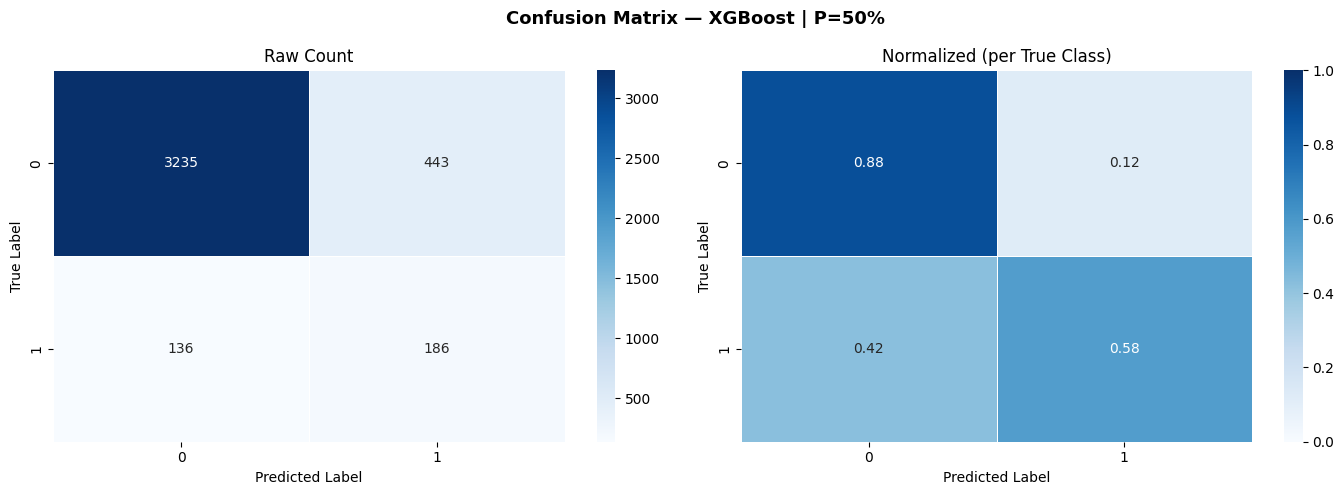


  [LightGBM]
  Training Time : 1.5871s
              precision    recall  f1-score   support

           0       0.96      0.88      0.92      3678
           1       0.30      0.58      0.39       322

    accuracy                           0.86      4000
   macro avg       0.63      0.73      0.66      4000
weighted avg       0.91      0.86      0.88      4000



/opt/homebrew/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


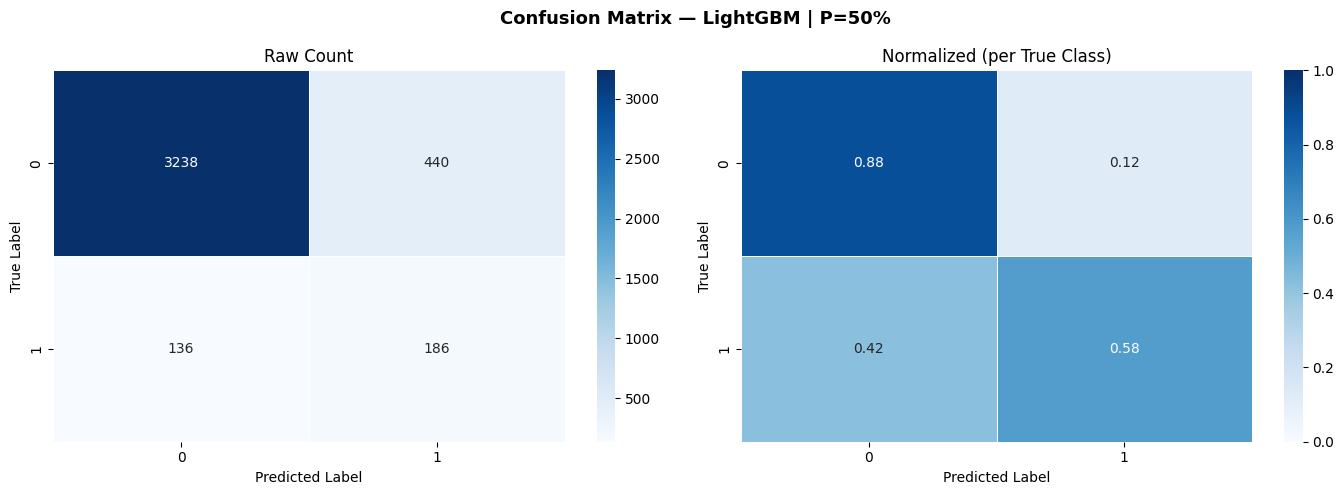


  [CatBoost]
  Training Time : 1.2218s
              precision    recall  f1-score   support

           0       0.96      0.88      0.92      3678
           1       0.29      0.58      0.38       322

    accuracy                           0.85      4000
   macro avg       0.62      0.73      0.65      4000
weighted avg       0.91      0.85      0.87      4000



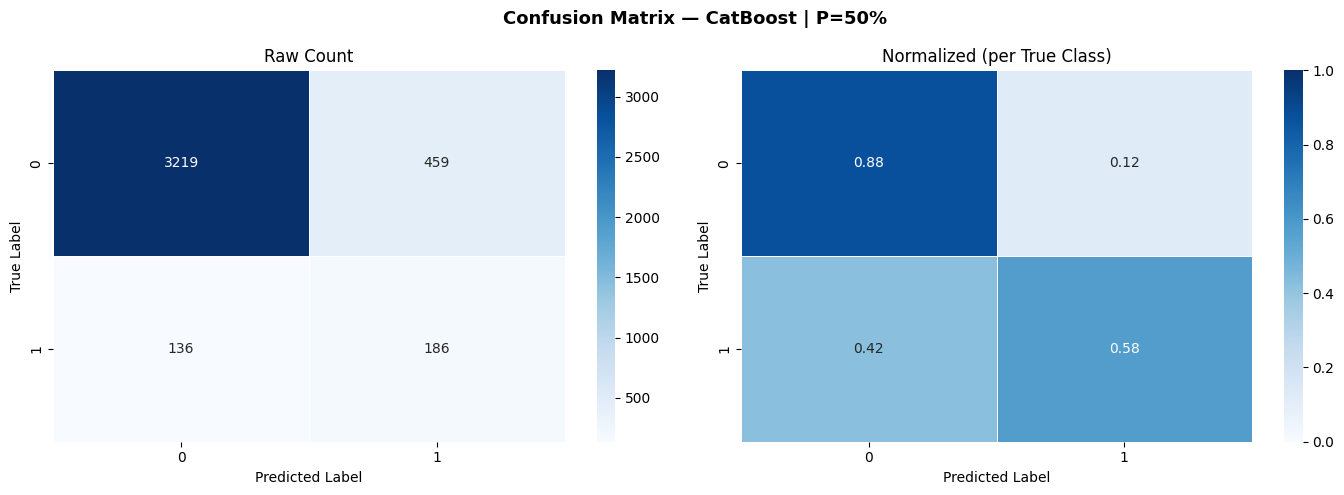


  [RandomForest]
  Training Time : 0.5917s
              precision    recall  f1-score   support

           0       0.98      0.74      0.84      3678
           1       0.21      0.79      0.33       322

    accuracy                           0.74      4000
   macro avg       0.59      0.76      0.58      4000
weighted avg       0.91      0.74      0.80      4000



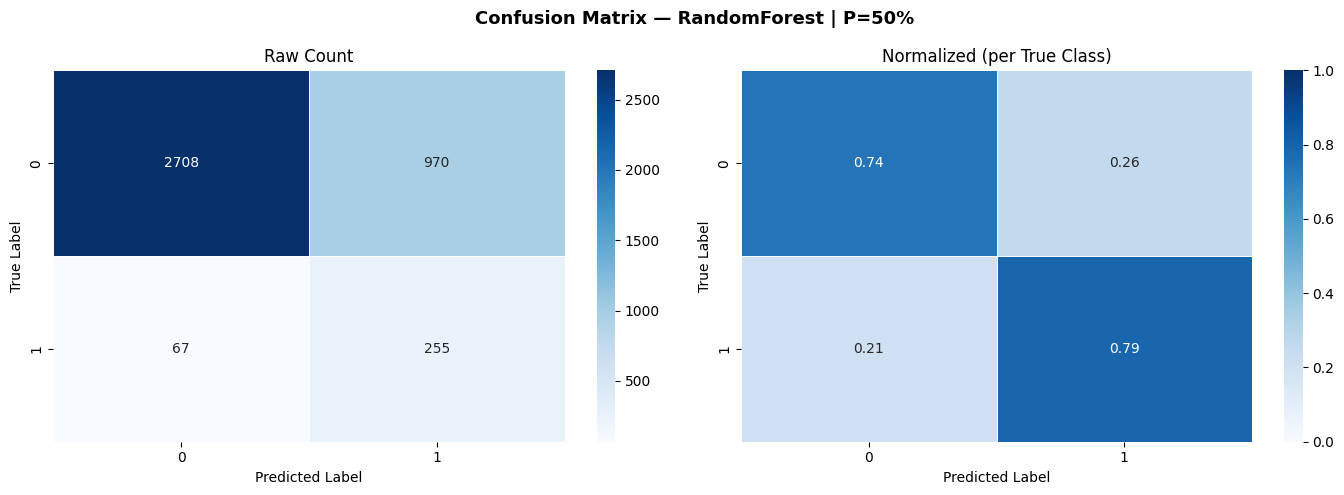


  [ExtraTrees]
  Training Time : 0.4139s
              precision    recall  f1-score   support

           0       0.98      0.68      0.81      3678
           1       0.19      0.86      0.31       322

    accuracy                           0.70      4000
   macro avg       0.59      0.77      0.56      4000
weighted avg       0.92      0.70      0.77      4000



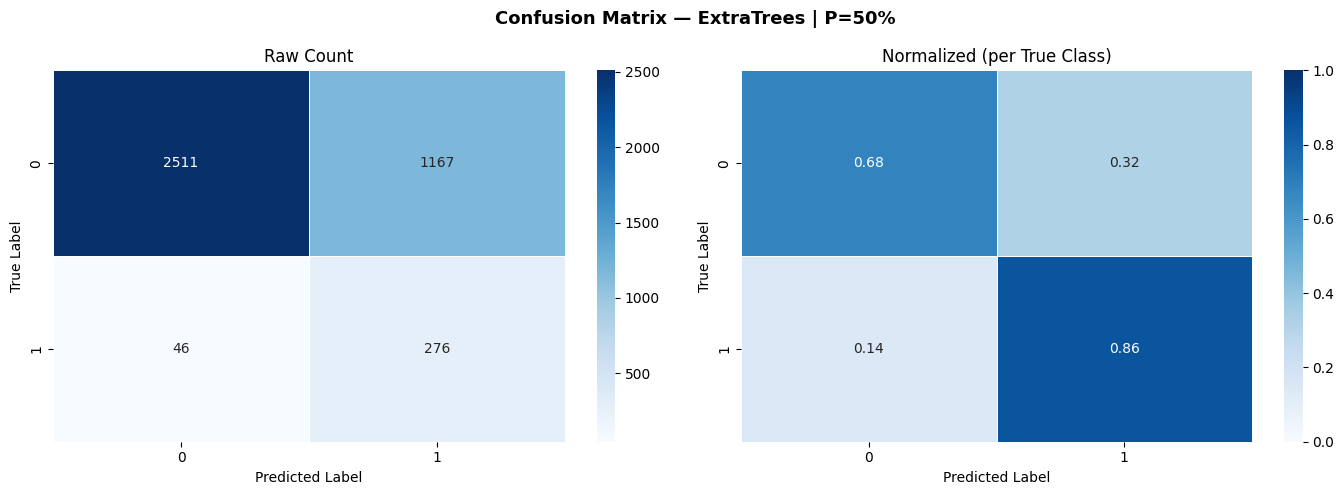


  [GradientBoosting]
  Training Time : 7.4899s
              precision    recall  f1-score   support

           0       0.96      0.85      0.90      3678
           1       0.26      0.62      0.37       322

    accuracy                           0.83      4000
   macro avg       0.61      0.73      0.64      4000
weighted avg       0.91      0.83      0.86      4000



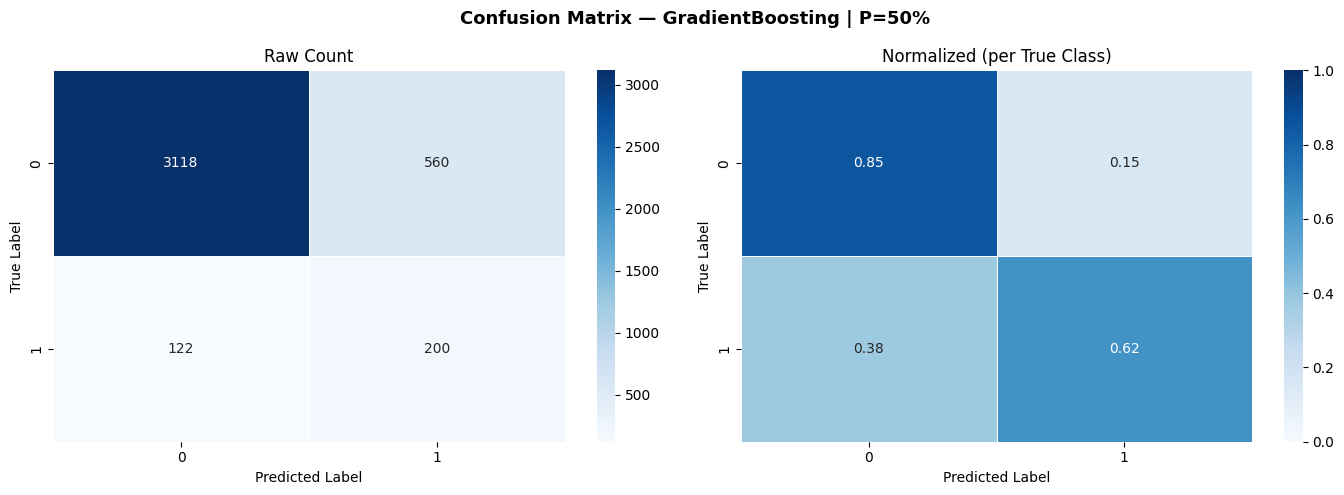


  [LogisticRegression]
  Training Time : 0.0581s
              precision    recall  f1-score   support

           0       0.98      0.68      0.80      3678
           1       0.19      0.87      0.32       322

    accuracy                           0.70      4000
   macro avg       0.59      0.78      0.56      4000
weighted avg       0.92      0.70      0.76      4000



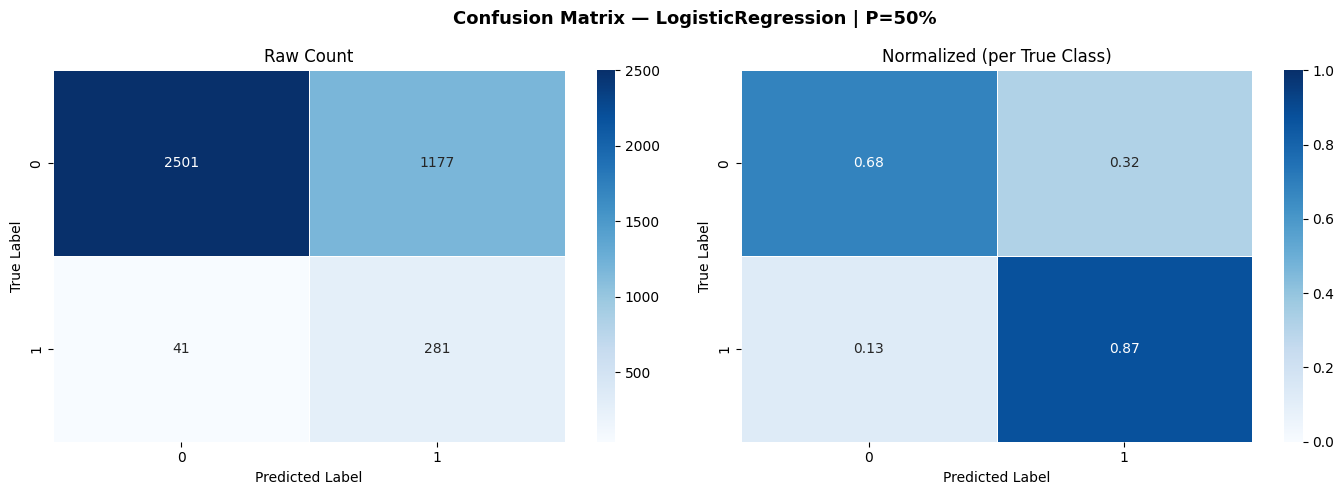


  [KNN]
  Training Time : 0.0035s
              precision    recall  f1-score   support

           0       0.97      0.78      0.86      3678
           1       0.21      0.68      0.32       322

    accuracy                           0.77      4000
   macro avg       0.59      0.73      0.59      4000
weighted avg       0.90      0.77      0.82      4000



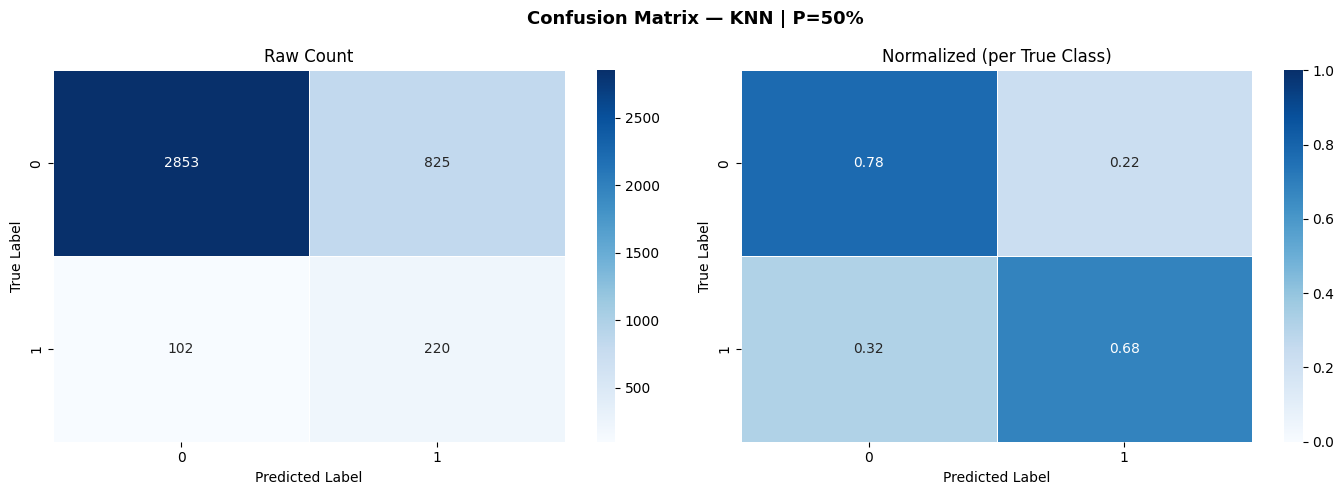

Kuartil:  50%|█████     | 1/2 [00:14<00:14, 14.12s/it]


  Kuartil Q=3 (75%) → 27 fitur
  Shape train : (16000, 27) → (21774, 27)



  [XGBoost]
  Training Time : 0.7889s
              precision    recall  f1-score   support

           0       0.95      0.93      0.94      3678
           1       0.35      0.41      0.38       322

    accuracy                           0.89      4000
   macro avg       0.65      0.67      0.66      4000
weighted avg       0.90      0.89      0.90      4000



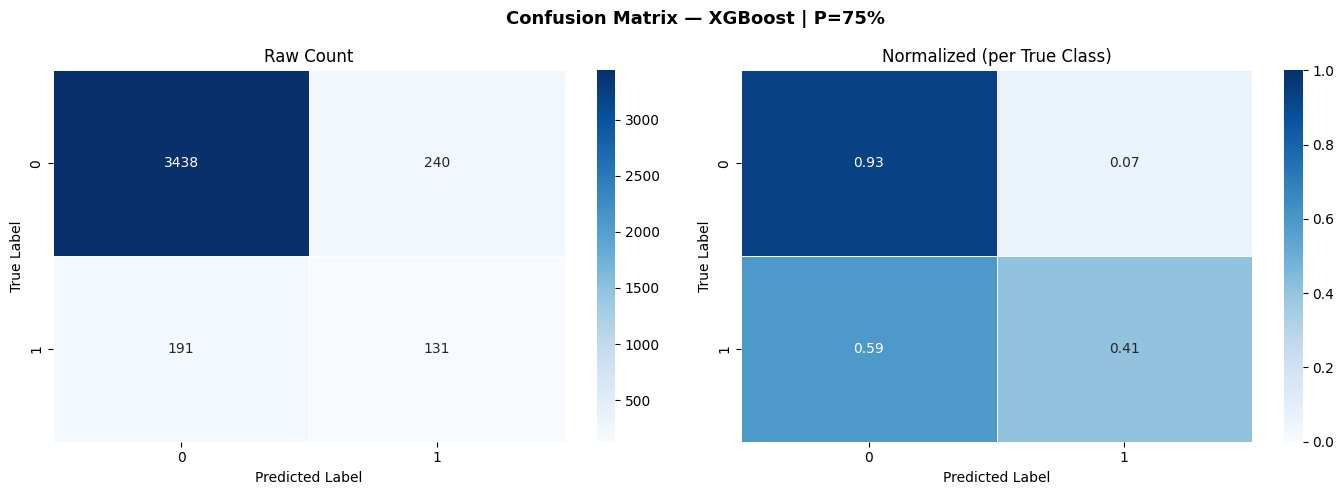


  [LightGBM]
  Training Time : 1.6381s
              precision    recall  f1-score   support

           0       0.95      0.93      0.94      3678
           1       0.35      0.42      0.38       322

    accuracy                           0.89      4000
   macro avg       0.65      0.67      0.66      4000
weighted avg       0.90      0.89      0.89      4000



/opt/homebrew/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


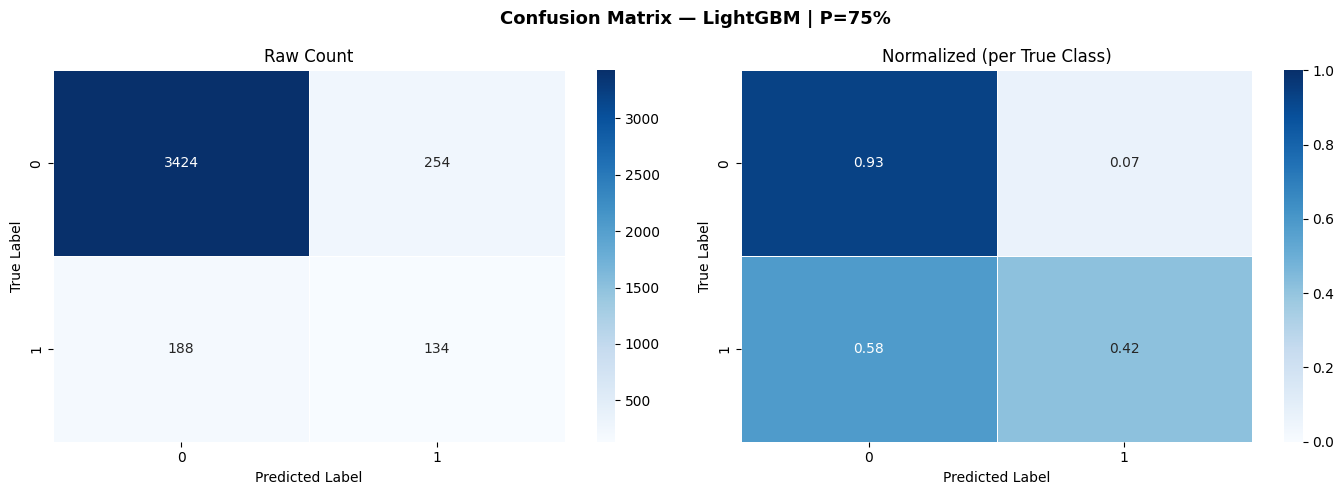


  [CatBoost]
  Training Time : 1.2453s
              precision    recall  f1-score   support

           0       0.95      0.94      0.94      3678
           1       0.35      0.39      0.37       322

    accuracy                           0.89      4000
   macro avg       0.65      0.66      0.65      4000
weighted avg       0.90      0.89      0.90      4000



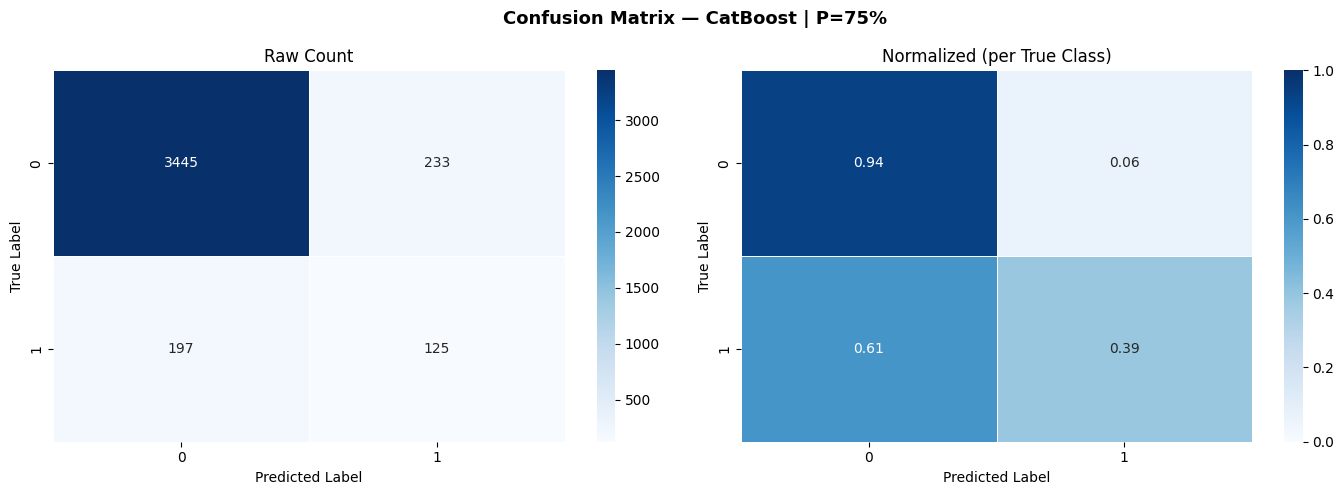


  [RandomForest]
  Training Time : 0.7690s
              precision    recall  f1-score   support

           0       0.96      0.84      0.89      3678
           1       0.25      0.61      0.35       322

    accuracy                           0.82      4000
   macro avg       0.60      0.72      0.62      4000
weighted avg       0.90      0.82      0.85      4000



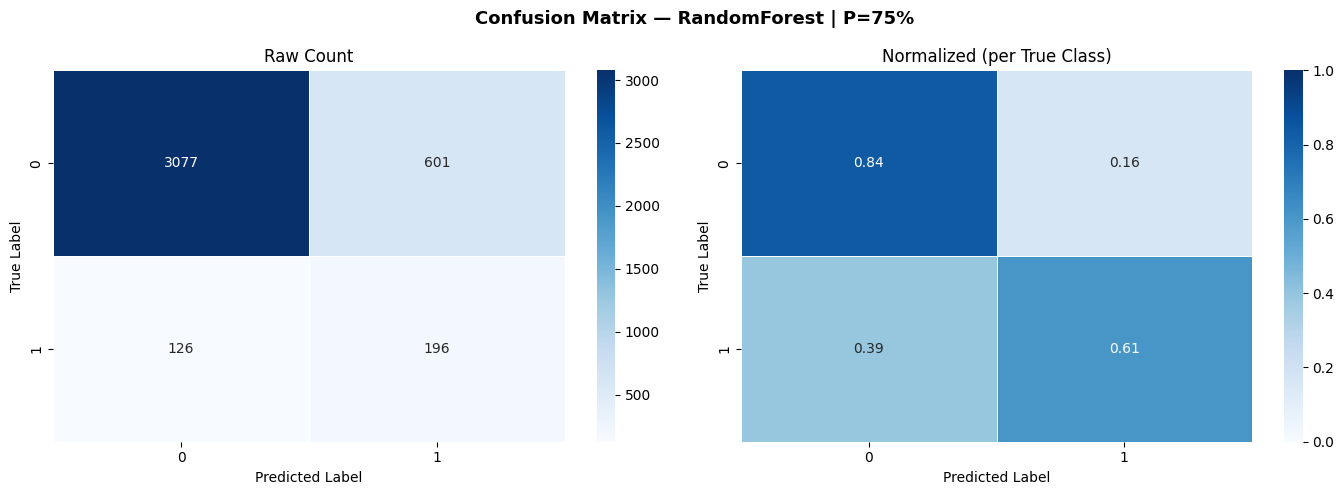


  [ExtraTrees]
  Training Time : 0.3659s
              precision    recall  f1-score   support

           0       0.97      0.73      0.84      3678
           1       0.20      0.78      0.32       322

    accuracy                           0.74      4000
   macro avg       0.59      0.75      0.58      4000
weighted avg       0.91      0.74      0.80      4000



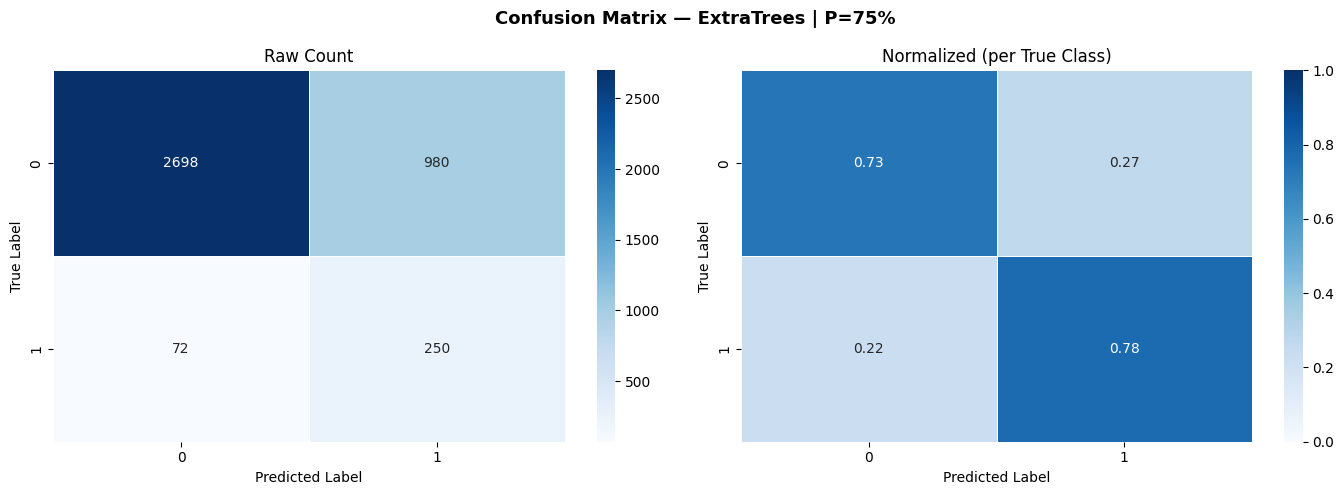


  [GradientBoosting]
  Training Time : 15.3205s
              precision    recall  f1-score   support

           0       0.95      0.93      0.94      3678
           1       0.35      0.41      0.38       322

    accuracy                           0.89      4000
   macro avg       0.65      0.67      0.66      4000
weighted avg       0.90      0.89      0.89      4000



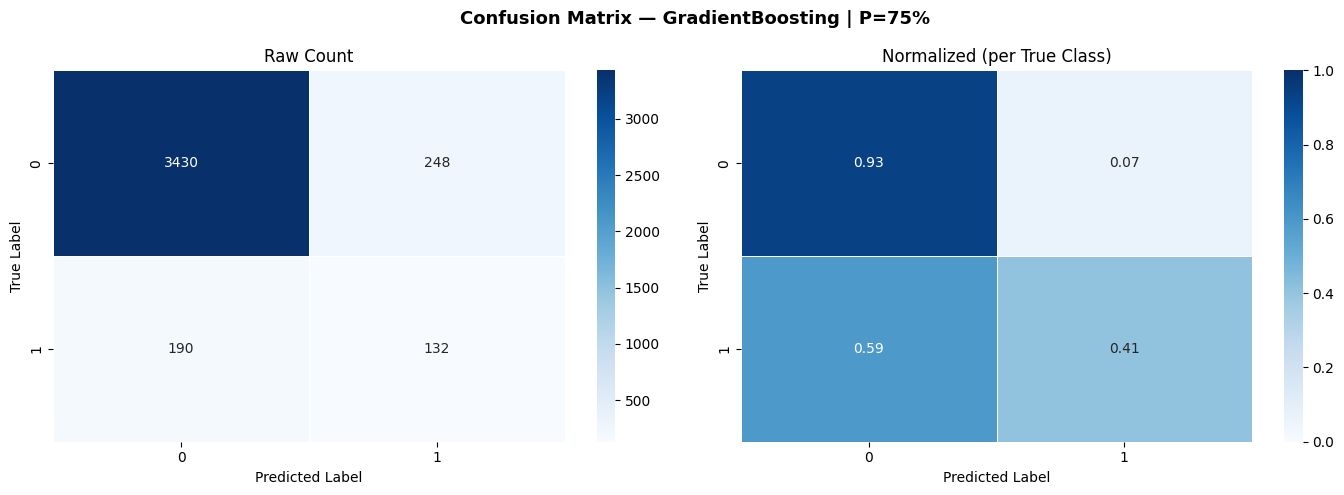


  [LogisticRegression]
  Training Time : 0.0754s
              precision    recall  f1-score   support

           0       0.98      0.71      0.82      3678
           1       0.20      0.84      0.33       322

    accuracy                           0.72      4000
   macro avg       0.59      0.77      0.57      4000
weighted avg       0.92      0.72      0.78      4000



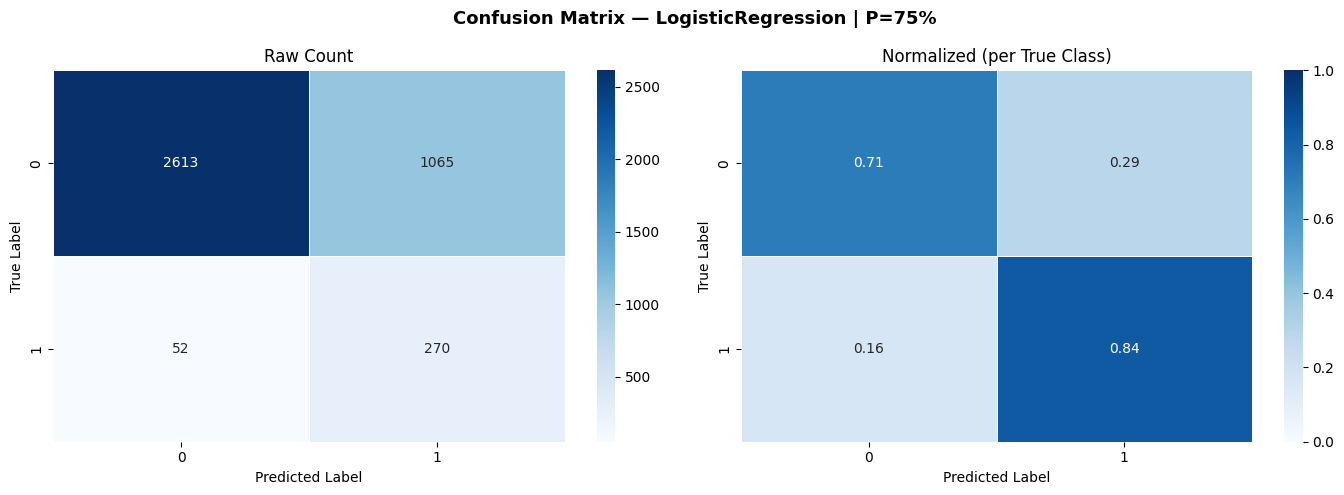


  [KNN]
  Training Time : 0.0031s
              precision    recall  f1-score   support

           0       0.97      0.75      0.84      3678
           1       0.20      0.70      0.31       322

    accuracy                           0.74      4000
   macro avg       0.58      0.72      0.57      4000
weighted avg       0.90      0.74      0.80      4000



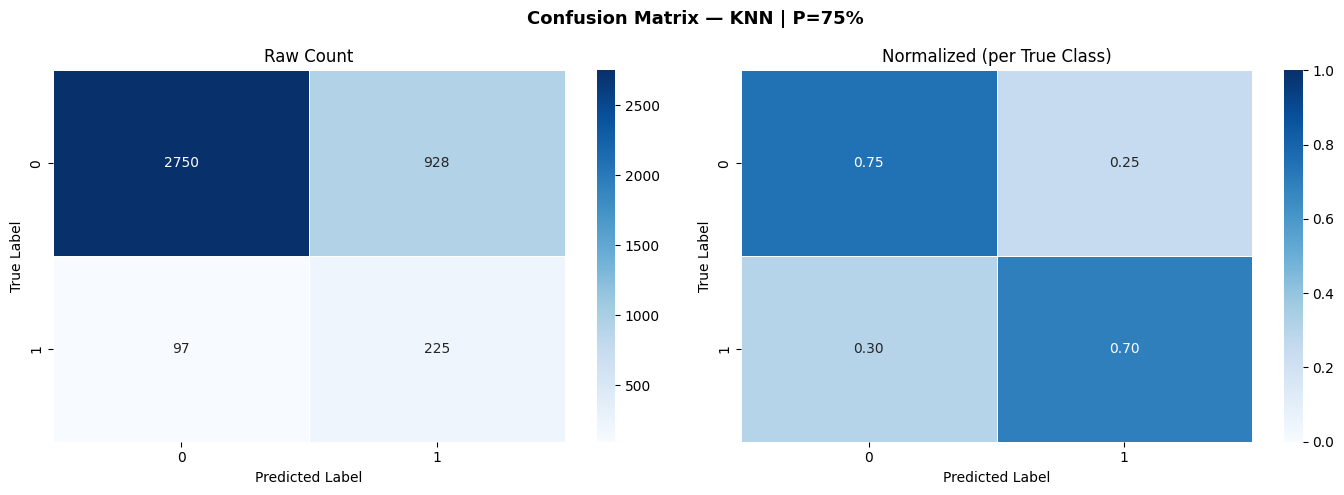

Kuartil: 100%|██████████| 2/2 [00:36<00:00, 18.07s/it]


── Perbandingan Semua Kombinasi (SMOTEENN) ──
                        Kuartil N Fitur               Model Accuracy  F1 Macro F1 Weighted Precision    Recall Training Time
Q3_XGBoost             Q3 (75%)      27             XGBoost  0.89225  0.659541    0.895698  0.650234   0.67079        0.7889
Q3_LightGBM            Q3 (75%)      27            LightGBM   0.8895  0.658417    0.894136  0.646656  0.673545        1.6381
Q3_GradientBoosting    Q3 (75%)      27    GradientBoosting   0.8905  0.658026    0.894588  0.647441  0.671255       15.3205
Q2_LightGBM            Q2 (50%)      18            LightGBM    0.856  0.655363    0.875985  0.628408  0.729005        1.5871
Q2_XGBoost             Q2 (50%)      18             XGBoost  0.85525  0.654514    0.875462  0.627682  0.728597        0.8558
Q3_CatBoost            Q3 (75%)      27            CatBoost   0.8925  0.654452    0.895081  0.647535  0.662425        1.2453
Q2_CatBoost            Q2 (50%)      18            CatBoost  0.85125  0.650047

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

from imblearn.combine import SMOTEENN
from sklearn.metrics import (
    f1_score, recall_score, precision_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score  # ← ditambahkan
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier

from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
import time


# ── ASUMSI: variabel berikut sudah tersedia sebelum script ini dijalankan ───
# X_train, X_test, y_train, y_test  → DataFrame/array hasil split
# feat_imp_df                        → DataFrame dengan kolom 'feature' (urut dari paling penting)
# ────────────────────────────────────────────────────────────────────────────


# ── 1. KONFIGURASI ───────────────────────────────────────────────────────────
kuartils = [2, 3]  # kuartil fitur yang akan dicoba (Q2 = 50%, Q3 = 75%)

resamplers = {
    'SMOTEENN' : SMOTEENN(random_state=42),
    'NoResample': None,  # baseline tanpa resampling
}

N_total = len(feat_imp_df)  # total jumlah fitur

# ── 2. MODEL ─────────────────────────────────────────────────────────────────
models = {
    'XGBoost': XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='logloss', random_state=42, n_jobs=-1
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1, verbose=-1
    ),
    'CatBoost': CatBoostClassifier(
        iterations=300, depth=6, learning_rate=0.05,
        random_state=42, verbose=0
    ),
    'RandomForest': RandomForestClassifier(
        n_estimators=300, max_depth=6,
        random_state=42, n_jobs=-1
    ),
    'ExtraTrees': ExtraTreesClassifier(
        n_estimators=300, max_depth=6,
        random_state=42, n_jobs=-1
    ),
    'GradientBoosting': GradientBoostingClassifier(
        n_estimators=300, learning_rate=0.05,
        random_state=42
    ),
    'LogisticRegression': LogisticRegression(
        max_iter=1000, random_state=42
    ),
    'KNN': KNeighborsClassifier(
        n_neighbors=5
    ),
}
# ── 3. Loop kuartil × model ──────────────────────────────────────────────────
results_all   = {}
conf_matrices = {}

for Q in tqdm(kuartils, desc="Kuartil"):
    N_FEATURES        = int(np.ceil(N_total * Q / 4))
    selected_features = feat_imp_df['feature'].head(N_FEATURES).tolist()

    X_train_q = X_train[selected_features]
    X_test_q  = X_test[selected_features]

    # ✅ Resample dulu (di luar loop model, per kuartil)
    X_res, y_res = SMOTEENN(random_state=42).fit_resample(X_train_q, y_train)

    # ✅ Scale setelah resample, fit sekali per kuartil (di luar loop model)
    scaler = MinMaxScaler()
    X_res_scaled  = scaler.fit_transform(X_res)
    X_test_scaled = scaler.transform(X_test_q)

    print(f"\n{'='*60}")
    print(f"  Kuartil Q={Q} ({Q*25}%) → {N_FEATURES} fitur")
    print(f"  Shape train : {X_train_q.shape} → {X_res.shape}")
    print(f"{'='*60}")

    for model_name, clf in tqdm(models.items(), desc=f"Q={Q}", leave=False):
        print(f"\n  [{model_name}]")

        # ✅ Gunakan clone agar lebih aman
        from sklearn.base import clone
        clf_fit = clone(clf)

        start = time.time()
        clf_fit.fit(X_res_scaled, y_res)   # ✅ langsung pakai yang sudah di-scale
        train_time = time.time() - start
        print(f"  Training Time : {train_time:.4f}s")

        y_pred = clf_fit.predict(X_test_scaled)
        report = classification_report(y_test, y_pred, output_dict=True)

        print(classification_report(y_test, y_pred, target_names=[str(x) for x in class_labels]))

        plot_confusion_matrix(y_test, y_pred, model_name, Q*25, class_labels)

        key = f'Q{Q}_{model_name}'
        conf_matrices[key] = confusion_matrix(y_test, y_pred)
        results_all[key] = {
            'Kuartil'      : f'Q{Q} ({Q*25}%)',
            'N Fitur'      : N_FEATURES,
            'Model'        : model_name,
            'Accuracy'     : report['accuracy'],
            'F1 Macro'     : report['macro avg']['f1-score'],
            'F1 Weighted'  : report['weighted avg']['f1-score'],
            'Precision'    : report['macro avg']['precision'],
            'Recall'       : report['macro avg']['recall'],
            'Training Time': round(train_time, 4),
        }


# ── 4. Tabel perbandingan ─────────────────────────────────────────────────────
results_df = pd.DataFrame(results_all).T.round(4)
print("\n── Perbandingan Semua Kombinasi (SMOTEENN) ──")
print(results_df.sort_values('F1 Macro', ascending=False).to_string())


# ── 5. Kombinasi terbaik ──────────────────────────────────────────────────────
best = results_df.sort_values('F1 Macro', ascending=False).iloc[0]
print(f"\n✅ Kombinasi terbaik:")
print(f"   Kuartil   : {best['Kuartil']}")
print(f"   N Fitur   : {best['N Fitur']}")
print(f"   Model     : {best['Model']}")
print(f"   F1 Macro  : {best['F1 Macro']}")